In [15]:
import os

In [16]:
from langgraph.graph import MessagesState, StateGraph, END, START
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

import operator
from langchain_core.messages import AnyMessage

from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages

from langgraph.prebuilt import tools_condition # this is the checker for the
from langchain_tavily import TavilySearch

In [17]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.3-70b-versatile")

In [18]:
def multiply(a: int, b: int) -> int:
    """
    Multiply a and b.
    Args:
        a: first int
        b: second int
    """
    return a * b
     

def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b
     

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b 

In [19]:
search = TavilySearch(max_results=2)

In [20]:
search.invoke("who is a current president of USA?")

{'query': 'who is a current president of USA?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/President_of_the_United_States',
   'title': 'President of the United States - Wikipedia',
   'content': 'Donald Trump is the 47th and current president since January 20, 2025.',
   'score': 0.8729662,
   'raw_content': None},
  {'url': 'https://www.usa.gov/presidents',
   'title': 'Presidents, vice presidents, and first ladies - USAGov',
   'content': 'The 47th and current president of the United States is Donald John Trump. ... Ask USA.gov a question at. 1-844-USAGOV1 (1-844-872-4681).',
   'score': 0.8682137,
   'raw_content': None}],
 'response_time': 0.81,
 'request_id': 'aaac84d9-ece2-44b9-8ac5-b56185fb1f44'}

In [21]:
tools = [add, multiply, divide, search]

In [22]:
llm_with_tools=llm.bind_tools(tools)

In [23]:
sys_msg = SystemMessage(content="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs.")

In [24]:
def reasoner(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

In [25]:
builder = StateGraph(MessagesState)

builder.add_node("reasoner", reasoner)

builder.add_node("tools", ToolNode(tools)) # for the tools

builder.add_edge(START, "reasoner")

builder.add_conditional_edges(
    "reasoner",
    # If the latest message (result) from node reasoner is a tool call -> tools_condition routes to tools
    # If the latest message (result) from node reasoner is a not a tool call -> tools_condition routes to END
    tools_condition,
)

builder.add_edge("tools", "reasoner")
react_graph = builder.compile()

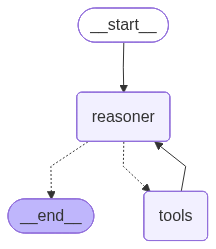

In [26]:
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [27]:
messages = [HumanMessage(content="What is 2 times of narendramodi's age?")]

In [28]:
messages = react_graph.invoke({"messages": messages})

In [29]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 times of narendramodi's age?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (mdxd40jej)
 Call ID: mdxd40jej
  Args:
    query: Narendra Modi age
    search_depth: basic
================================= Tool Message =================================
Name: tavily_search

{"query": "Narendra Modi age", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.instagram.com/p/DOscmuIEm6b", "title": "Prime Minister Narendra Modi turns 75 today. By the time his current ...", "content": "#HTNumberTheory: Prime Minister Narendra Modi turns 75 today. By the time his current term ends in May 2029, he will be almost 79.", "score": 0.8319231, "raw_content": null}, {"url": "https://www.facebook.com/Timesnow/posts/prime-minister-narendra-modi-turns-75-today-born-in-gujarats-vadnagar-in-1950-pm/1271295251708401", "

### Finance chatbot

In [30]:
import yfinance as yf

def get_stock_price(ticker: str) -> float:
    """Gets a stock price from Yahoo Finance.

    Args:
        ticker: ticker str
    """
    # """This is a tool for getting the price of a stock when passed a ticker symbol"""
    stock = yf.Ticker(ticker)
    return stock.info['previousClose']
     

In [31]:
get_stock_price("AAPL")

275.15

In [39]:
# Cell 18 (corrected) — don't mutate messages, don't re-add the query on every loop
def reasoner(state):
    messages = state["messages"]
    sys_msg = SystemMessage(content=(
        "You are a helpful assistant tasked with using search, "
        "the yahoo finance tool and performing arithmetic on a set of inputs."
    ))
    result = llm_with_tools.invoke([sys_msg] + messages)
    return {"messages": [result]}

In [40]:
tools = [add, multiply, divide, search, get_stock_price]

In [41]:
llm_with_tools = llm.bind_tools(tools)

In [42]:
class GraphState(TypedDict):
    """State of the graph."""
    query: str
    finance: str
    final_answer: str
    # intermediate_steps: Annotated[list[tuple[AgentAction, str]], operator.add]
    messages: Annotated[list[AnyMessage], operator.add]

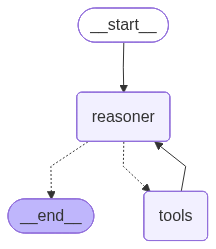

In [43]:
workflow = StateGraph(GraphState)

workflow.add_node("reasoner", reasoner)
workflow.add_node("tools", ToolNode(tools)) # for the tools
workflow.add_edge(START, "reasoner")

workflow.add_conditional_edges(
    "reasoner",
    # If the latest message (result) from node reasoner is a tool call -> tools_condition routes to tools
    # If the latest message (result) from node reasoner is a not a tool call -> tools_condition routes to END
    tools_condition,
)
workflow.add_edge("tools", "reasoner")
react_graph = workflow.compile()

display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [44]:
response = react_graph.invoke({
    "messages": [HumanMessage(content="What is the stock price of Apple? Add 1000 to it.")]
})

In [45]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the stock price of Apple? Add 1000 to it.
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (e5ecanxhm)
 Call ID: e5ecanxhm
  Args:
    ticker: AAPL
================================= Tool Message =================================
Name: get_stock_price

275.15
================================== Ai Message ==================================
Tool Calls:
  add (snbxr2pkt)
 Call ID: snbxr2pkt
  Args:
    a: 275
    b: 1000
================================= Tool Message =================================
Name: add

1275
================================== Ai Message ==================================

The current stock price of Apple is $275.15. Adding 1000 to it results in $1275.15.
